GPU 확인 및 패키지 설치

In [1]:
# GPU 확인
import torch
print("GPU 사용 가능:", torch.cuda.is_available())
print("GPU 이름:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

# 필요 패키지 설치
!pip install -q mediapipe kaggle gradio

GPU 사용 가능: True
GPU 이름: Tesla T4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 9.3 MB/s eta 0:00:00


API키 업로드

In [2]:
from google.colab import files
import os

# kaggle.json 파일 업로드 (발급받은 API 키 파일)
files.upload()  # kaggle.json 선택

# Kaggle 인증 설정
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle 인증 완료!")

Saving kaggle.json to kaggle.json
Kaggle 인증 완료!


데이터셋 다운로드

In [3]:
# LeapGestRecog — 10가지 제스처, 빠른 실습용 (~200MB)
!kaggle datasets download -d gti-upm/leapgestrecog -p /content/gesture --unzip

import os
base_path = "/content/gesture"
for root, dirs, files_list in os.walk(base_path):
    level = root.replace(base_path, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    if level == 2:  # 파일 목록은 2단계까지만 출력
        for f in files_list[:3]:
            print(f"{'  '*(level+1)}{f}")

Dataset URL: https://www.kaggle.com/datasets/gti-upm/leapgestrecog
License(s): CC-BY-NC-SA-4.0
100% 2.13G/2.13G [00:20<00:00, 110MB/s] 

gesture/
  leapGestRecog/
    00/
      03_fist/
      09_c/
      06_index/
      07_ok/
      01_palm/
      04_fist_moved/
      10_down/
      08_palm_moved/
      05_thumb/
      02_l/
    04/
      03_fist/
      09_c/
      06_index/
      07_ok/
      01_palm/
      04_fist_moved/
      10_down/
      08_palm_moved/
      05_thumb/
      02_l/
    03/
      03_fist/
      09_c/
      06_index/
      07_ok/
      01_palm/
      04_fist_moved/
      10_down/
      08_palm_moved/
      05_thumb/
      02_l/
    07/
      03_fist/
      09_c/
      06_index/
      07_ok/
      01_palm/
      04_fist_moved/
      10_down/
      08_palm_moved/
      05_thumb/
      02_l/
    08/
      03_fist/
      09_c/
      06_index/
      07_ok/
      01_palm/
      04_fist_moved/
      10_down/
      08_palm_moved/
      05_thumb/
      02_l/
    05/
      03_

데이터 샘플 시각화

제스처 클래스 (10개): ['01_palm', '02_l', '03_fist', '04_fist_moved', '05_thumb', '06_index', '07_ok', '08_palm_moved', '09_c', '10_down']


/tmp/ipykernel_8351/4291654676.py:26: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8351/4291654676.py:26: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8351/4291654676.py:26: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8351/4291654676.py:26: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8351/4291654676.py:26: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8351/4291654676.py:26: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8351/4291654676.py:26: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight

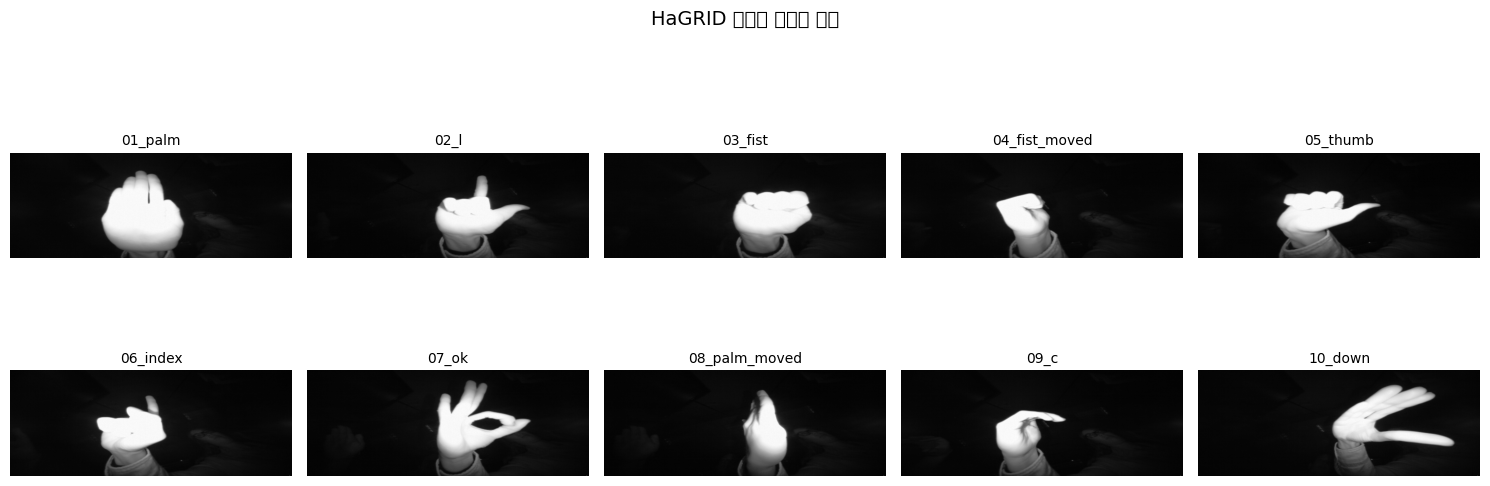

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os, random

# 경로 설정 (LeapGestRecog 기준)
base_path = "/content/gesture/leapGestRecog"

# 클래스 목록 확인
subject_path = os.path.join(base_path, os.listdir(base_path)[0])
classes = sorted(os.listdir(subject_path))
print(f"제스처 클래스 ({len(classes)}개):", classes)

# 각 클래스별 샘플 이미지 1장씩 시각화
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for idx, cls in enumerate(classes[:10]):
    cls_path = os.path.join(subject_path, cls)
    img_file = random.choice(os.listdir(cls_path))
    img = mpimg.imread(os.path.join(cls_path, img_file))
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(cls, fontsize=10)
    axes[idx].axis('off')

plt.suptitle("HaGRID 제스처 클래스 샘플", fontsize=14)
plt.tight_layout()
plt.show()

클래스 분포 확인

/tmp/ipykernel_8351/457830052.py:23: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8351/457830052.py:23: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8351/457830052.py:23: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8351/457830052.py:23: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8351/457830052.py:23: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8351/457830052.py:23: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8351/457830052.py:23: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/t

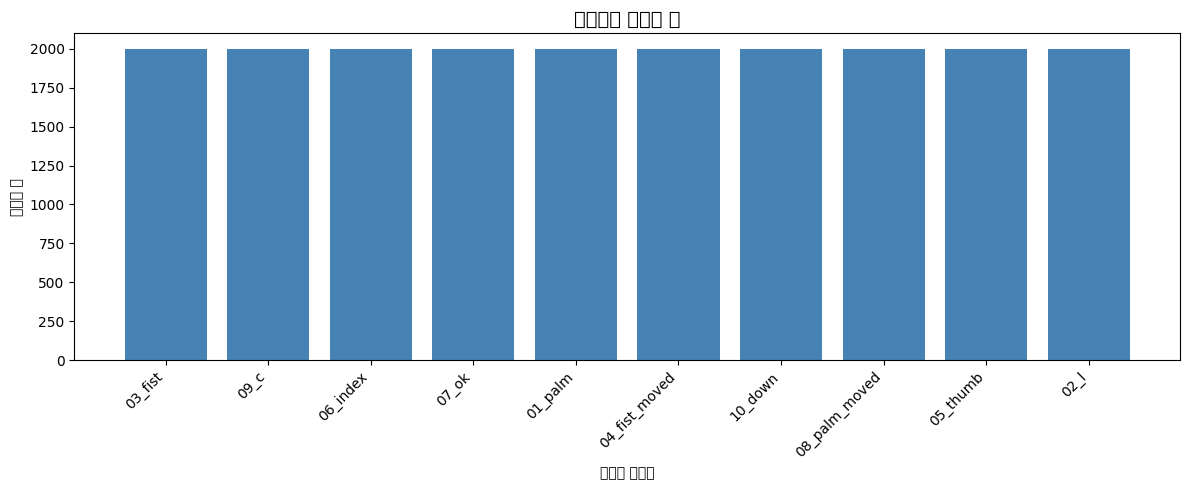


총 이미지 수: 20,000장
클래스 수: 10개


In [5]:
import matplotlib.pyplot as plt
from collections import defaultdict

base_path = "/content/gesture/leapGestRecog"
class_counts = defaultdict(int)

for subject in os.listdir(base_path):
    subject_path = os.path.join(base_path, subject)
    if not os.path.isdir(subject_path):
        continue
    for cls in os.listdir(subject_path):
        cls_path = os.path.join(subject_path, cls)
        if os.path.isdir(cls_path):
            class_counts[cls] += len(os.listdir(cls_path))

# 막대 그래프
plt.figure(figsize=(12, 5))
plt.bar(class_counts.keys(), class_counts.values(), color='steelblue')
plt.title("클래스별 이미지 수", fontsize=14)
plt.xlabel("제스처 클래스")
plt.ylabel("이미지 수")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\n총 이미지 수: {sum(class_counts.values()):,}장")
print(f"클래스 수: {len(class_counts)}개")

데이터셋 전처리 및 로더

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torchvision.models import MobileNet_V2_Weights
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import os

# 1. GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"현재 사용하는 디바이스: {device}")

# 2. LeapGestRecog 맞춤형 데이터셋 클래스 (사람 00~09 폴더 구조 무시하고 제스처만 추출)
class LeapGestRecogDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.classes = sorted(['01_palm', '02_l', '03_fist', '04_fist_moved', '05_thumb',
                               '06_index', '07_ok', '08_palm_moved', '09_c', '10_down'])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        # 00~09 폴더 순회하며 이미지와 라벨 수집
        for subject in sorted(os.listdir(root_dir)):
            subject_path = os.path.join(root_dir, subject)
            if not os.path.isdir(subject_path): continue

            for gesture in sorted(os.listdir(subject_path)):
                gesture_path = os.path.join(subject_path, gesture)
                if not os.path.isdir(gesture_path): continue

                for img_name in os.listdir(gesture_path):
                    if img_name.endswith(('.png', '.jpg', '.jpeg')):
                        self.image_paths.append(os.path.join(gesture_path, img_name))
                        self.labels.append(self.class_to_idx[gesture])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        # 흑백(L) 모드로 이미지 열기
        image = Image.open(img_path).convert('L')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)
        return image, label

# 3. 전처리 파이프라인 (흑백 -> 3채널 RGB 확장, 224x224 리사이즈)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 4. 데이터셋 및 DataLoader 생성 (경로는 기존 다운로드 경로 사용)
base_path = "/content/gesture/leapGestRecog" # 기존 노트북 파일의 경로
full_dataset = LeapGestRecogDataset(root_dir=base_path, transform=transform)

train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

batch_size = 64 # T4 GPU 메모리에 맞게 넉넉히 64로 설정
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"총 이미지 수: {len(full_dataset)} (학습: {len(train_dataset)}, 테스트: {len(test_dataset)})")
print(f"분류할 제스처 수: {len(full_dataset.classes)}개")

현재 사용하는 디바이스: cuda
총 이미지 수: 20000 (학습: 16000, 테스트: 4000)
분류할 제스처 수: 10개


MobilNetV2 학습 및 평가 루프

In [7]:
# 1. 사전 학습된 MobileNetV2 불러오기
model = models.mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)

# 2. 분류기(Classifier) 수정: 마지막 노드를 1000개에서 10개(제스처 수)로 변경
num_classes = len(full_dataset.classes)
model.classifier[1] = nn.Linear(model.last_channel, num_classes)
model = model.to(device)

# 3. 오차 함수와 최적화 도구
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005) # 안정적인 학습을 위해 학습률 약간 낮춤

# 4. 본격적인 학습 루프
num_epochs = 5 # 5번만 돌아도 95% 이상 정확도가 나옵니다

print("=== MobileNetV2 학습 시작 ===")
for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total

    # 평가 모드 (테스트 데이터로 정확도 검증)
    model.eval()
    test_correct, test_total = 0, 0
    with torch.no_grad():
        for test_images, test_labels in test_loader:
            test_images, test_labels = test_images.to(device), test_labels.to(device)
            test_outputs = model(test_images)
            _, test_predicted = torch.max(test_outputs.data, 1)
            test_total += test_labels.size(0)
            test_correct += (test_predicted == test_labels).sum().item()

    test_acc = 100 * test_correct / test_total

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

print("=== 학습 완료! ===")

# (선택) 학습된 모델 가중치 파일 저장
torch.save(model.state_dict(), "/content/gesture_mobilenetv2.pth")
print("모델이 성공적으로 저장되었습니다: /content/gesture_mobilenetv2.pth")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 160MB/s]


=== MobileNetV2 학습 시작 ===
Epoch [1/5] - Train Acc: 97.66% | Test Acc: 100.00%
Epoch [2/5] - Train Acc: 99.86% | Test Acc: 99.75%
Epoch [3/5] - Train Acc: 99.76% | Test Acc: 99.88%
Epoch [4/5] - Train Acc: 99.96% | Test Acc: 100.00%
Epoch [5/5] - Train Acc: 99.99% | Test Acc: 100.00%
=== 학습 완료! ===
모델이 성공적으로 저장되었습니다: /content/gesture_mobilenetv2.pth


시각화

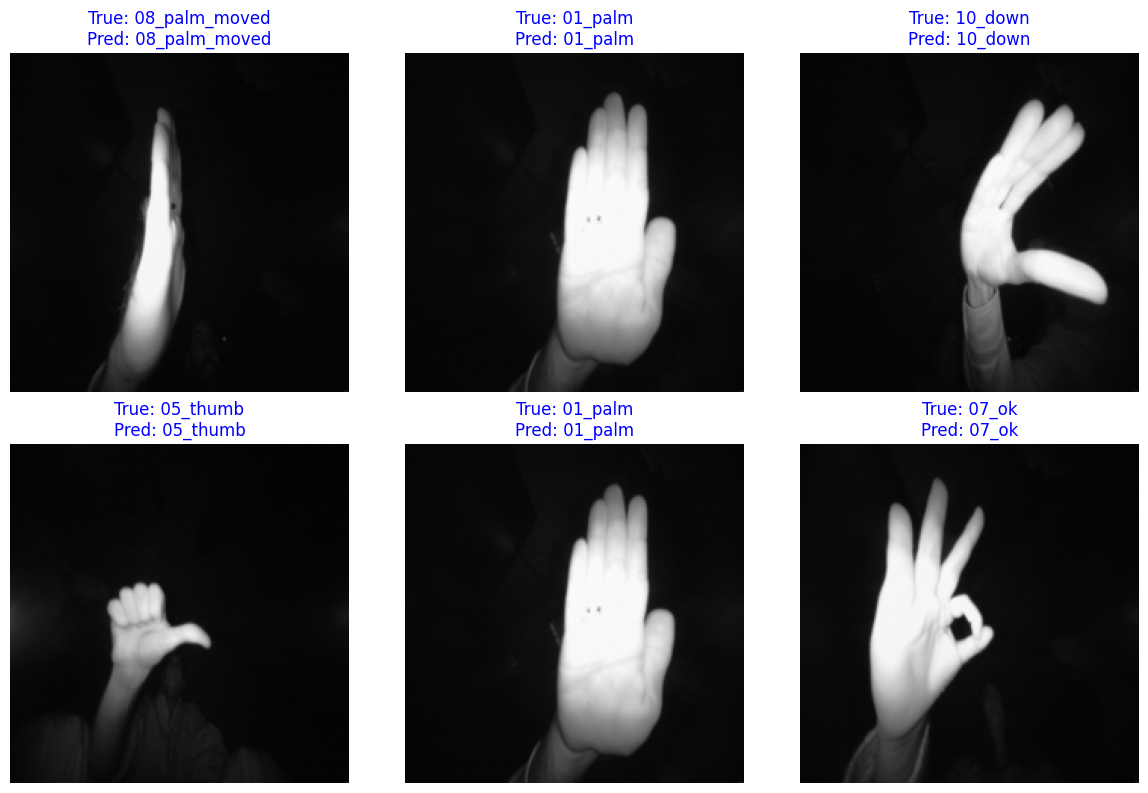

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import random

# 모델 평가 모드
model.eval()

# 테스트 데이터셋에서 무작위로 6개 샘플 추출
indices = random.sample(range(len(test_dataset)), 6)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

class_names = full_dataset.classes

with torch.no_grad():
    for i, idx in enumerate(indices):
        image, label = test_dataset[idx]

        # 모델 예측을 위해 차원 확장 (C, H, W) -> (1, C, H, W) 및 GPU 이동
        img_input = image.unsqueeze(0).to(device)
        output = model(img_input)
        _, predicted = torch.max(output, 1)

        # 시각화를 위해 정규화 해제 및 형태 변경
        img_display = image.permute(1, 2, 0).numpy()
        # 정규화 시 사용했던 mean, std 값으로 복원
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_display = std * img_display + mean
        img_display = np.clip(img_display, 0, 1)

        true_label = class_names[label]
        pred_label = class_names[predicted.item()]

        # 결과 출력 (정답과 예측이 같으면 파란색, 다르면 빨간색 텍스트)
        color = 'blue' if true_label == pred_label else 'red'

        axes[i].imshow(img_display)
        axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", color=color)
        axes[i].axis('off')

plt.tight_layout()
plt.show()

혼돈행렬

테스트 데이터에 대한 예측을 진행 중입니다...

=== Classification Report ===
               precision    recall  f1-score   support

      01_palm       1.00      1.00      1.00       380
         02_l       1.00      1.00      1.00       370
      03_fist       1.00      1.00      1.00       409
04_fist_moved       1.00      1.00      1.00       407
     05_thumb       1.00      1.00      1.00       395
     06_index       1.00      1.00      1.00       416
        07_ok       1.00      1.00      1.00       384
08_palm_moved       1.00      1.00      1.00       436
         09_c       1.00      1.00      1.00       411
      10_down       1.00      1.00      1.00       392

     accuracy                           1.00      4000
    macro avg       1.00      1.00      1.00      4000
 weighted avg       1.00      1.00      1.00      4000



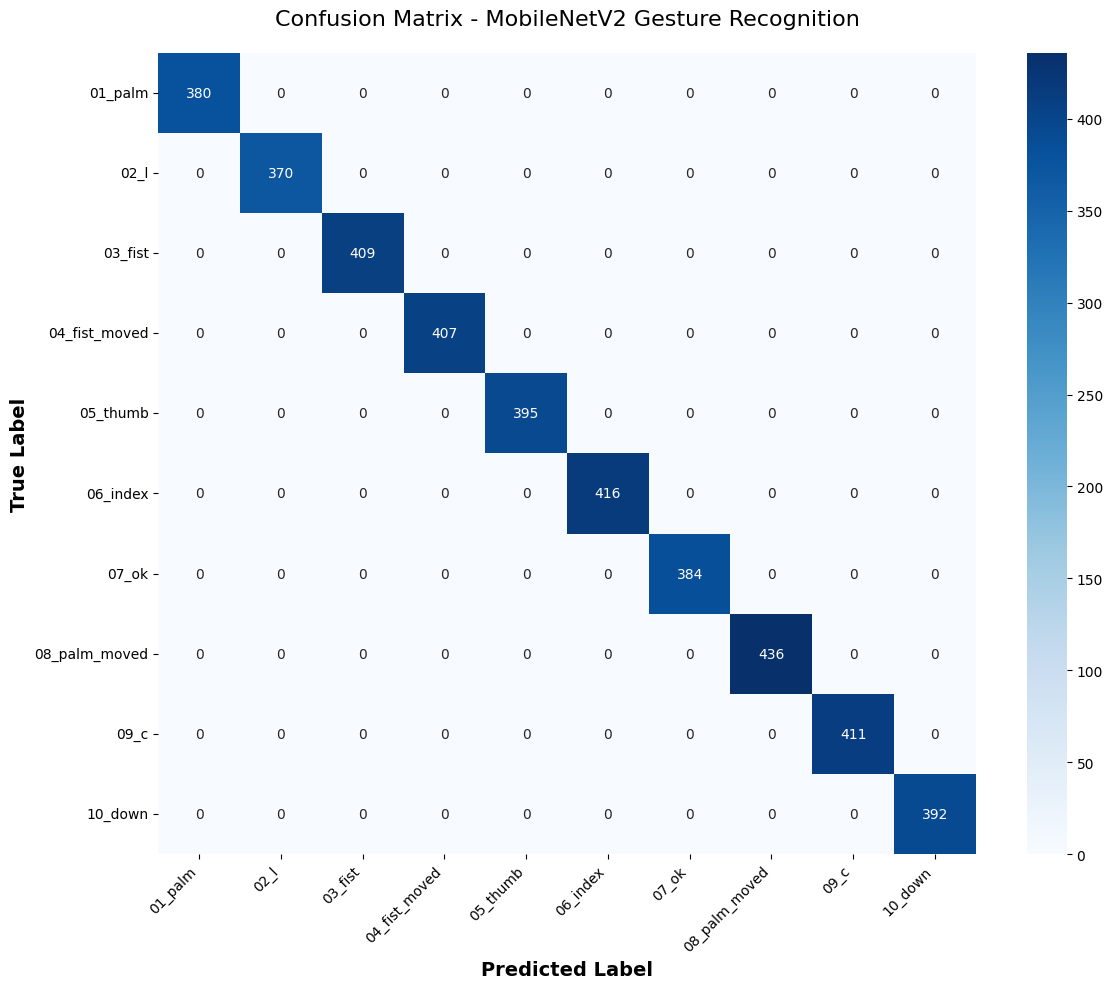

In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. 모델을 평가 모드로 전환
model.eval()

all_preds = []
all_labels = []

print("테스트 데이터에 대한 예측을 진행 중입니다...")

# 2. 테스트 데이터셋 전체 예측 수행
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        # CPU로 내린 뒤 numpy 배열로 변환하여 리스트에 추가
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 클래스 이름 리스트 가져오기
class_names = full_dataset.classes

# 3. Classification Report 출력 (클래스별 정밀도, 재현율, F1-score)
print("\n=== Classification Report ===")
print(classification_report(all_labels, all_preds, target_names=class_names))

# 4. Confusion Matrix 계산 및 시각화
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
# fmt='d'는 정수 형태로 출력, cmap='Blues'는 파란색 계열의 색상 맵
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=14, fontweight='bold')
plt.title('Confusion Matrix - MobileNetV2 Gesture Recognition', fontsize=16, pad=20)

# x축 라벨이 길어 겹칠 수 있으므로 45도 회전
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()